In [1]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter
# import subroutines
# import vis_eulag

plt.style.use('latex_default.mplstyle')

In [2]:
folder = "/work/bd0620/b309199/patagonia"
# simulations = ["pata_1D_pha0_mpfl15", "pata_1D_pha1_mpfl15", "pata_1D_tide_mpfl15"]
simulations = ["pata_2D_pha0", "pata_2D_fitzroy", "pata_2D_darwin"]
simulations = ["pata_1D_pha0"]
simulations = ["pata_2D_fitz_hr"]
simulations = ["debeto_1D_pha0"]

lidar_sets = []
xy_sets = []
for sim in simulations:
    fpath = os.path.join(folder, sim)
    ds, ds_xzslices, ds_yzslices, ds_xyslices, ds_lidars = plt_helper.preprocess_eulag_output(fpath, load_ds=False)
    xy_sets.append(ds_xyslices)

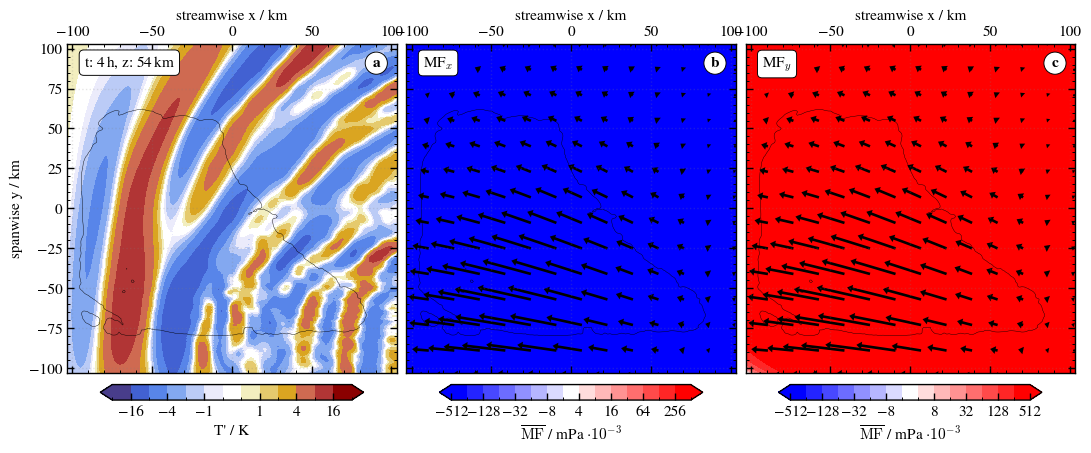

In [7]:
"""Momentum flux"""
import importlib
importlib.reload(plt_helper)
sim = 0
level = 1
tstamp = 4 # h
t = int(tstamp * 3600 / (ds.nslice * ds.dt00))

dsxy = xy_sets[sim][level]
CUTOFF_X = 150*1000

xlim  = [ds.xcr.min().values+ds.dxabL/1000,ds.xcr.max().values-ds.dxabR/1000]
ylim  = [ds.ycr.min().values+ds.dyab/1000,ds.ycr.max().values-ds.dyab/1000]
# ylim  = [-300, 650]

surf_factor = 5
cmap   = cmaps.get_wave_cmap()
clev, clev_l = plt_helper.get_colormap_bins_and_labels(max_level=32)
norm = BoundaryNorm(boundaries=clev , ncolors=cmap.N, clip=True)

cmap_mf = plt.get_cmap('RdBu_r')
cmap_mf = plt.get_cmap('bwr')
clev_mf, clev_l_mf = plt_helper.get_colormap_bins_and_labels(max_level=256)
norm_mf = BoundaryNorm(boundaries=clev_mf, ncolors=cmap_mf.N, clip=True)

tloc, tenv = plt_helper.get_eulag_t_and_tenv(dsxy['th'][t,:,:].values, dsxy['the'][t,:,:].values, dsxy['p'][t,:,:].values, dsxy['ppe'][t,:,:].values, ds.cap, ds.pref00)
# epm = 1/2*(ds.g/ds.bv)**2 * ((tloc-tenv)/tenv)**2
# epm = 1/2*(ds.g/ds.bv)**2 * (dsxy['th'][t,:,:]/dsxy['the'][t,:,:])**2
# epv = dsxy['rh0'][t,:,:]*epm
# epm = filter.gaussian_fft_smoothing(epm, CUTOFF_X, CUTOFF_X, ds.dy00, ds.dx00)
# epm = np.where(epm>clev_ep[0],epm,np.nan)
mfx = dsxy['rh0'][t,:,:] * dsxy['w'][t,:,:] * (dsxy['u'][t,:,:]-dsxy['ue'][t,:,:]) 
mfx = filter.gaussian_fft_smoothing(mfx, CUTOFF_X, CUTOFF_X, ds.dy00, ds.dx00)
mfy = dsxy['rh0'][t,:,:] * dsxy['w'][t,:,:] * (dsxy['v'][t,:,:]-dsxy['ve'][t,:,:]) 
mfy = filter.gaussian_fft_smoothing(mfy, CUTOFF_X, CUTOFF_X, ds.dy00, ds.dx00)

# mPa
mfx = mfx * 10**3
mfy = mfy * 10**3
cbar_mf_label = r"$\overline{\mathrm{MF}}$ / mPa"
if level > 0: # mPa * 10^3 
    mfx = mfx * 10**3
    mfy = mfy * 10**3
    cbar_mf_label = r"$\overline{\mathrm{MF}}$ / mPa $\cdot 10^{-3}$"

# ep  = subroutines.fft_gaussian_xy(ep,nx_avg,ny_avg=None)
# mfx_obs = 2 * ep * lambdaz/(-lambdax)

# - ENERGY - #
efx = (dsxy['u'][t,:,:]-dsxy['ue'][t,:,:]) * dsxy['p'][t,:,:] # h14, EFx1
efy = (dsxy['v'][t,:,:]-dsxy['ve'][t,:,:]) * dsxy['p'][t,:,:] # h14, EFx1
efz = dsxy['w'][t,:,:] * dsxy['p'][t,:,:] # h13, EFz1
efx = filter.gaussian_fft_smoothing(efx, CUTOFF_X, CUTOFF_X, ds.dy00, ds.dx00)
efy = filter.gaussian_fft_smoothing(efy, CUTOFF_X, CUTOFF_X, ds.dy00, ds.dx00)
# efx = np.where(abs(efx)>0.00003,efz,np.nan)
efmax = np.max(np.sqrt(efx**2+efy**2))
efx = efx/efmax
efy = efy/efmax
zbot = 60

"""Figure stuff"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [8,1], 'width_ratios': [1,1,1]} 
fig, axes = plt.subplots(2,3, sharex=True, sharey=True, figsize=(13,5), gridspec_kw=gskw)

ax0 = axes[0,0]
ax1 = axes[0,1]
ax2 = axes[0,2]
for ax in axes[-1,0:3]:
    ax.set_axis_off()

ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
contf_th = ax0.contourf(ds.xcr, ds.ycr, tloc-tenv, cmap=cmap, norm=norm, levels=clev, extend='both')
contf_mf = ax1.contourf(ds.xcr, ds.ycr, mfx, cmap=cmap_mf, norm=norm_mf, levels=clev_mf, extend='both')
contf_mf = ax2.contourf(ds.xcr, ds.ycr, mfy, cmap=cmap_mf, norm=norm_mf, levels=clev_mf, extend='both')

nn = 20
Q = ax1.quiver(ds.xcr[0,::nn],ds.ycr[::nn,0], efx[::nn, ::nn], efy[::nn,::nn], 
                  angles='xy', color="k", width=0.008, scale=6, headwidth=3,headlength=2,headaxislength=2)
Q = ax2.quiver(ds.xcr[0,::nn],ds.ycr[::nn,0], efx[::nn, ::nn], efy[::nn,::nn], 
                  angles='xy', color="k", width=0.008, scale=6, headwidth=3,headlength=2,headaxislength=2)

### - Topography - ###
if ds.itopo == 1:
    amp = dsxy.zcrtopo.max()
    amp = 1200
    topo_levels=np.linspace(20,surf_factor*amp,3)
else:
    if ds.amp < 0:
        topo_levels=np.linspace(surf_factor*ds.amp,-surf_factor*ds.amp,12)
    else: 
        topo_levels=np.linspace(-2*surf_factor*ds.amp,2*surf_factor*ds.amp,24)
ctopo = "k"
lwtopo = 0.3
ax0.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)
ax1.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)
ax2.contour(ds.xcr, ds.ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)

numstr = ['a','b','c']
for ip, ax in enumerate(axes[0,0:3]):
    ax.text(0.95, 0.93, numstr[ip], transform=ax.transAxes, horizontalalignment='right', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', labeltop=True)
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('streamwise x / km')
    ax.grid()
    
ax0.text(0.05, 0.93, "t: " + str(tstamp) + "$\,$h, z: " + str(int(dsxy.zpos)) + "$\,$km", transform=ax0.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax1.text(0.05, 0.93, "MF$_x$", transform=ax1.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax2.text(0.05, 0.93, "MF$_y$", transform=ax2.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

ax0.set_xlim(xlim)
ax0.set_ylim(ylim)
ax0.set_ylabel('spanwise y / km')

cbar = fig.colorbar(contf_th, ax=axes[-1,0], orientation='horizontal', ticks=clev_l, shrink=0.8, fraction=1,aspect=17) # anchor=(0,0)
cbar.set_label(r"T' / K")
cbar = fig.colorbar(contf_mf, ax=axes[-1,1], orientation='horizontal', shrink=0.8, fraction=1, aspect=17)
cbar.set_label(cbar_mf_label)
cbar = fig.colorbar(contf_mf, ax=axes[-1,2], orientation='horizontal', ticks=clev_l_mf, shrink=0.8, fraction=1, aspect=17)
cbar.set_label(cbar_mf_label)

fig_title = simulations[sim] + "_mf_z" + str(int(dsxy.zpos)) + "_t" + str(tstamp) + "h.png"
imagefolder = "../data/figures"
os.makedirs(imagefolder, exist_ok=True)
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=120, bbox_inches='tight')